Visualization
Goal: Visualize several aspects of the EEG data to better understand the signals used in the classification analysis.

In [17]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from mne.decoding import CSP

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [18]:
file_path = "/Users/vaneeza/EEG_BCI_Project/data/BCICIV_2a_gdf/A01T.gdf"
raw = mne.io.read_raw_gdf(file_path, preload=True)
print (raw)

Extracting GDF parameters from /Users/vaneeza/EEG_BCI_Project/data/BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>


In [19]:
raw_plot = raw.copy()
eog_channels = [
    "EOG-left",
    "EOG-central",
    "EOG-right"
]

for channel in eog_channels:

    if channel in raw_plot.ch_names:

        raw_plot.drop_channels(channel)

rename_channels = {
    "EEG-Fz": "Fz",
    "EEG-C3": "C3",
    "EEG-Cz": "Cz",
    "EEG-C4": "C4",
    "EEG-Pz": "Pz"
}

raw_plot.rename_channels(rename_channels)

<RawGDF | A01T.gdf, 22 x 672528 (2690.1 s), ~112.9 MiB, data loaded>

Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Left Hand Code: 7
Right Hand Code: 8
{'left_hand': 7, 'right_hand': 8}
Not setting metadata
144 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1126 original time points ...
0 bad epochs dropped
<Epochs | 144 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~30.9 MiB, data loaded,
 'left_hand': 72
 'right_hand': 72>
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
    Using multitaper spectrum estimation with 7 

/var/folders/gd/px5t4f7j76b9__cj30279q000000gp/T/ipykernel_98741/591370499.py:63: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  ).plot()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


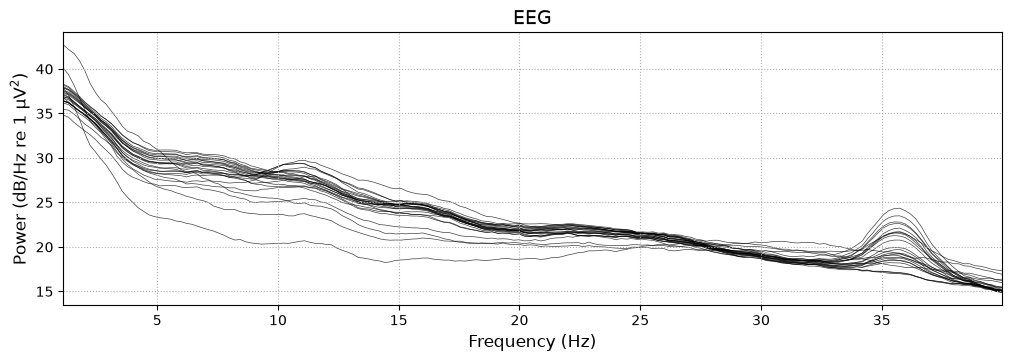

In [20]:
# event identification
events, event_id = mne.events_from_annotations(raw, event_id = "auto")
print (event_id)

left_hand_code = event_id["769"]
right_hand_code = event_id["770"]
print("Left Hand Code:", left_hand_code)
print("Right Hand Code:", right_hand_code)

motor_events = {
    "left_hand": left_hand_code,
    "right_hand": right_hand_code
}
print(motor_events)

# Each epoch will begin 0.5 seconds before the cue and end 4 seconds after.
# This marks each trial of motor imagery. The 0.5 seconds prior to the cue is a baseline.
epochs = mne.Epochs(
    raw, events, event_id=motor_events, 
    tmin = -0.5, tmax =4.0, baseline = (-0.5,0), preload = True)
print(epochs)
epochs_plot = epochs.copy()
eog_channels = [
    "EOG-left",
    "EOG-central",
    "EOG-right"
]

epochs_plot.drop_channels(eog_channels)

channel_names = {
    "EEG-Fz": "Fz",
    "EEG-0": "FC3",
    "EEG-1": "FC1",
    "EEG-2": "FCz",
    "EEG-3": "FC2",
    "EEG-4": "FC4",
    "EEG-5": "C5",
    "EEG-C3": "C3",
    "EEG-6": "C1",
    "EEG-Cz": "Cz",
    "EEG-7": "C2",
    "EEG-C4": "C4",
    "EEG-8": "C6",
    "EEG-9": "CP3",
    "EEG-10": "CP1",
    "EEG-11": "CPz",
    "EEG-12": "CP2",
    "EEG-13": "CP4",
    "EEG-14": "P1",
    "EEG-Pz": "Pz",
    "EEG-15": "P2",
    "EEG-16": "POz"
}
epochs_plot.rename_channels(channel_names)

print(epochs_plot.ch_names)

# PSD - How much signal power exists at different frequencies?
epochs.compute_psd(
    fmin=1,
    fmax=40
).plot()

Power Spectral Density (PSD) shows how the EEG power  is distributed across different frequencies. I used a 8-30 Hz band pass filter during preprocessing to focus on the mu and beta frequency ranges as they are relevant for motor imagery research. The PSD allows for the visualization of the frequency content of the EEG rather than viewing only the signal over a period of time.

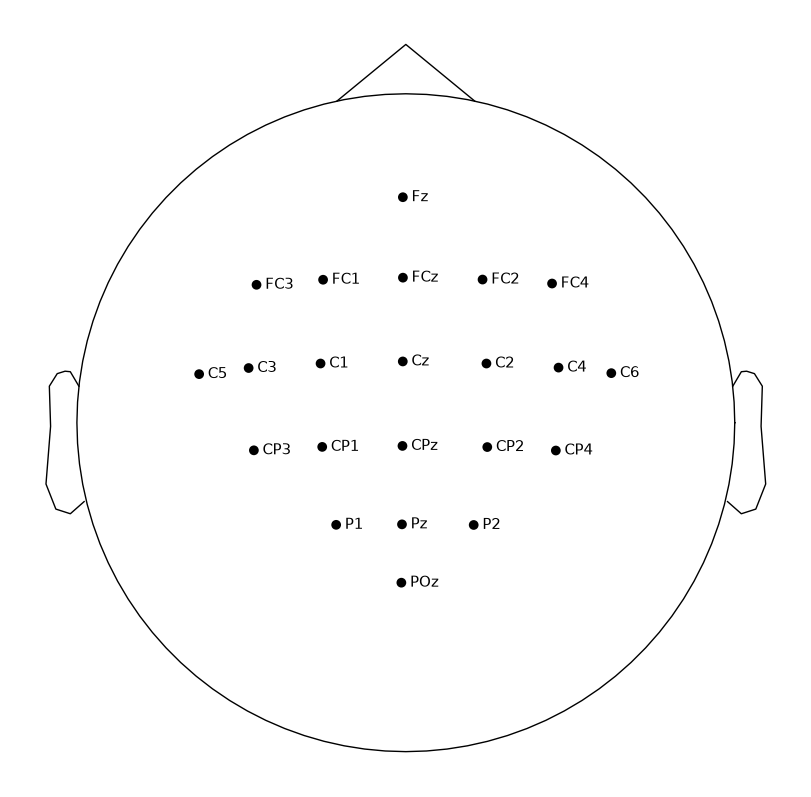

In [27]:


montage = mne.channels.make_standard_montage(
    "standard_1020"
)
epochs_plot.set_montage(montage)
fig = epochs_plot.plot_sensors(
    show_names=True,
    show=False
)

fig.savefig(
    "../figures/eeg_sensor_layout.png",
    dpi=300,
    bbox_inches="tight"
)
fig


EEG Electrode Locations
The EEG recordings use 22 electrodes distributed across the scalp. By using a standard 10-20 montage, MNE could visualize the physical locations of the electrodes.

In [22]:
# CSP
X_plot = epochs_plot.get_data()
y_plot = epochs_plot.events[:, 2]

csp_plot = CSP(
    n_components=6,
    log=True
)

csp_plot.fit( X_plot, y_plot)



# CSP patterns visualize spatial EEG patterns associated with discrimination between the two motor-imagery classes.

Computing rank from data with rank=None


    Using tolerance 0.0001 (2.2e-16 eps * 22 dim * 2.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.


,n_components,6
,log,True
,reg,None
,cov_est,'concat'
,transform_into,'average_power'
,norm_trace,False
,cov_method_params,None
,restr_type,'restricting'
,info,None
,rank,None
,component_order,'mutual_info'


NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


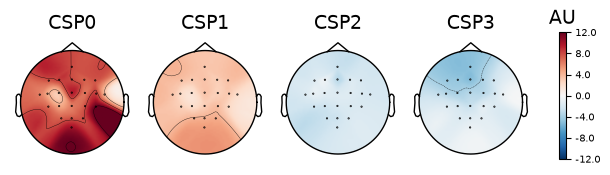

In [28]:
fig = csp_plot.plot_patterns(
    epochs_plot.info,
    ch_type="eeg",
    components=[0, 1, 2, 3],
    show=False
)

fig.savefig(
    "../figures/csp_spatial_patterns.png",
    dpi=300,
    bbox_inches="tight"
)
fig

CSP Spatial Patterns
CSP learns spatial patterns across EEG electrodes that help to distinguish between left-hand and right-hand motor imagery. The CSP scalp map shows how the different electrode locations contribute to the learned spatial components of classification.